# Análisis de Series Temporales en Ventas Retail

El formateo de fechas es una parte esencial de la visualización de datos, especialmente cuando se trabaja con series temporales.

Matplotlib, una de las bibliotecas más populares para la creación de gráficos en Python, ofrece herramientas flexibles para personalizar cómo se muestran las fechas en los gráficos.

Utilizando `DateFormatter` y los códigos de formato de `strftime`, puedes adaptar la presentación de las fechas para que se ajusten a las necesidades específicas de tu análisis o presentación.

A continuación, exploramos cómo se utiliza el formato `'%b %Y'` y otras opciones comunes para formatear fechas.

## ¿Qué hace `'%b %Y'`?

* `%b`: Representa el mes abreviado en texto (por ejemplo, `'Jan'`, `'Feb'`, `'Mar'`, etc.). Este formato es útil cuando se quiere mostrar el mes de manera compacta.
* `%Y`: Representa el año en cuatro dígitos (por ejemplo, `'2023'`, `'2024'`). Esto proporciona una indicación clara y completa del año.

Cuando se utiliza `'%b %Y'` en el `DateFormatter`, cada etiqueta del eje x se formatea como `Mes Año`. Por ejemplo, una fecha que corresponde a enero de 2023 se mostrará como `'Jan 2023'`.

## Otras Formas de Dar Formato a Fechas con `%`:

Matplotlib, a través de `DateFormatter`, permite una amplia personalización de cómo se muestran las fechas y horas utilizando códigos de formato de fecha y hora basados en el estándar de `strftime`. Aquí algunos ejemplos comunes:

* `%d`: Día del mes como número decimal (por ejemplo, `'01'`, `'15'`).
* `%B`: Nombre completo del mes (por ejemplo, `'January'`, `'February'`).
* `%m`: Mes como número decimal con ceros a la izquierda (por ejemplo, `'01'` para enero, `'12'` para diciembre).
* `%y`: Año como número de dos dígitos (por ejemplo, `'23'` para 2023).
* `%H`: Hora en formato de 24 horas (por ejemplo, `'14'` para las 2 PM).
* `%I`: Hora en formato de 12 horas (por ejemplo, `'02'` para las 2 PM).
* `%p`: AM o PM.
* `%M`: Minuto con ceros a la izquierda (por ejemplo, `'05'`).
* `%S`: Segundo con ceros a la izquierda (por ejemplo, `'09'`).
* `%A`: Nombre completo del día de la semana (por ejemplo, `'Monday'`, `'Tuesday'`).
* `%a`: Nombre abreviado del día de la semana (por ejemplo, `'Mon'`, `'Tue'`).

Al comprender y utilizar estos formatos, puedes mejorar la claridad y la estética de tus visualizaciones, asegurando que la información temporal se comunique de manera efectiva.

----------------------------------

El manejo de **series temporales** es fundamental cuando trabajamos con datos que incluyen fechas y tiempos. **Pandas** proporciona herramientas poderosas para manipular, analizar y visualizar series temporales de manera eficiente. Aquí te explico las operaciones clave que puedes realizar con **Pandas** para trabajar con datos de tipo temporal.

### 1. **Creación de Series Temporales**

#### Crear una serie de fechas:

Puedes crear una serie de fechas usando `pd.date_range()`.

In [1]:
import pandas as pd

# Crear una serie de fechas desde el 1 de enero de 2023, con 10 días de frecuencia
fechas = pd.date_range(start='2023-01-01', periods=10, freq='D')

print(fechas)

DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10'],
              dtype='datetime64[ns]', freq='D')


#### Crear un DataFrame con una columna de fechas:

In [2]:
# Crear un DataFrame con fechas y datos

data = pd.DataFrame({
    'fecha': pd.date_range('2023-01-01', periods=10, freq='D'),
    'valor': range(10)
})

print(data)

       fecha  valor
0 2023-01-01      0
1 2023-01-02      1
2 2023-01-03      2
3 2023-01-04      3
4 2023-01-05      4
5 2023-01-06      5
6 2023-01-07      6
7 2023-01-08      7
8 2023-01-09      8
9 2023-01-10      9


### 2. **Conversión de Fechas (Datetime)**

Si tienes una columna de fechas como texto, puedes convertirla a formato **datetime** usando `pd.to_datetime()`.

In [3]:
# Crear un DataFrame con fechas como cadenas

data = pd.DataFrame({
    'fecha': ['2023-01-01', '2023-01-02', '2023-01-03'],
    'valor': [10, 20, 30]
})

# Convertir la columna 'fecha' a formato datetime

data['fecha'] = pd.to_datetime(data['fecha'])

print(data.dtypes)

fecha    datetime64[ns]
valor             int64
dtype: object


### 3. **Indexación y Selección por Fechas**

Cuando trabajas con series temporales, a menudo querrás usar las fechas como índice. Esto facilita la selección de datos basados en intervalos de tiempo.

#### Establecer una columna de fechas como índice:

In [4]:
data.set_index('fecha', inplace=True)

print(data)

            valor
fecha            
2023-01-01     10
2023-01-02     20
2023-01-03     30


#### Selección de datos por fecha:

In [5]:
# Seleccionar datos de una fecha específica
print(data.loc['2023-01-02'])

# Seleccionar datos por rango de fechas
print(data.loc['2023-01-01':'2023-01-03'])

valor    20
Name: 2023-01-02 00:00:00, dtype: int64
            valor
fecha            
2023-01-01     10
2023-01-02     20
2023-01-03     30


### 4. **Resampling (Re-Muestreo)**

El **resampling** permite agrupar datos por diferentes frecuencias de tiempo (como días, meses, o años). Es útil para agregar, promediar o tomar la suma de datos en diferentes intervalos de tiempo.

#### Ejemplo de re-muestreo a frecuencia mensual:

In [6]:
# Crear un DataFrame con datos diarios

data = pd.DataFrame({
    'fecha': pd.date_range(start='2023-01-01', periods=100, freq='D'),
    'valor': range(100)
})

data.set_index('fecha', inplace=True)

# Re-muestrear a frecuencia mensual y sumar los valores
data_mensual = data.resample('D').sum()

print(data_mensual)

            valor
fecha            
2023-01-01      0
2023-01-02      1
2023-01-03      2
2023-01-04      3
2023-01-05      4
...           ...
2023-04-06     95
2023-04-07     96
2023-04-08     97
2023-04-09     98
2023-04-10     99

[100 rows x 1 columns]


#### Frecuencias comunes para resampling:

- D: Día.

- ME: Mes.

- YE: Año.

- h: Hora.

- min: Minuto.

### 5. **Shifting y Lagging**

El desplazamiento (`shift()`) se utiliza para mover datos hacia adelante o hacia atrás en el tiempo. Esto es útil para calcular diferencias entre períodos consecutivos.

#### Ejemplo de `shift()`:

In [7]:
#Desplazar los valores hacia abajo
data['valor_shift'] = data['valor'].shift(1)

print(data)

            valor  valor_shift
fecha                         
2023-01-01      0          NaN
2023-01-02      1          0.0
2023-01-03      2          1.0
2023-01-04      3          2.0
2023-01-05      4          3.0
...           ...          ...
2023-04-06     95         94.0
2023-04-07     96         95.0
2023-04-08     97         96.0
2023-04-09     98         97.0
2023-04-10     99         98.0

[100 rows x 2 columns]


#### Calcular la diferencia entre períodos:

In [8]:
# Calcular la diferencia entre un valor y el anterior

data['diferencia'] = data['valor'] - data['valor'].shift(1)

print(data)

            valor  valor_shift  diferencia
fecha                                     
2023-01-01      0          NaN         NaN
2023-01-02      1          0.0         1.0
2023-01-03      2          1.0         1.0
2023-01-04      3          2.0         1.0
2023-01-05      4          3.0         1.0
...           ...          ...         ...
2023-04-06     95         94.0         1.0
2023-04-07     96         95.0         1.0
2023-04-08     97         96.0         1.0
2023-04-09     98         97.0         1.0
2023-04-10     99         98.0         1.0

[100 rows x 3 columns]


### 6. **Ventanas Móviles (Rolling Windows)**

Las ventanas móviles permiten aplicar funciones (como media, suma, etc.) sobre ventanas deslizantes de datos temporales.

#### Ejemplo de media móvil:

In [9]:
# Calcular la media móvil de 3 días
data['media_movil'] = data['valor'].rolling(window=3).mean()

print(data)

            valor  valor_shift  diferencia  media_movil
fecha                                                  
2023-01-01      0          NaN         NaN          NaN
2023-01-02      1          0.0         1.0          NaN
2023-01-03      2          1.0         1.0          1.0
2023-01-04      3          2.0         1.0          2.0
2023-01-05      4          3.0         1.0          3.0
...           ...          ...         ...          ...
2023-04-06     95         94.0         1.0         94.0
2023-04-07     96         95.0         1.0         95.0
2023-04-08     97         96.0         1.0         96.0
2023-04-09     98         97.0         1.0         97.0
2023-04-10     99         98.0         1.0         98.0

[100 rows x 4 columns]


### 7. **Frecuencias de Fechas Personalizadas**

Pandas permite trabajar con diferentes frecuencias de tiempo, no solo días o meses. Puedes crear series de tiempo con frecuencias personalizadas, como días laborables (B), horas (H), semanas (W), etc.

#### Ejemplo de días laborables:

In [10]:
# Crear una serie temporal solo con días laborables
fechas_laborables = pd.date_range(start='2023-01-01', periods=10, freq='s')

print(fechas_laborables)

DatetimeIndex(['2023-01-01 00:00:00', '2023-01-01 00:00:01',
               '2023-01-01 00:00:02', '2023-01-01 00:00:03',
               '2023-01-01 00:00:04', '2023-01-01 00:00:05',
               '2023-01-01 00:00:06', '2023-01-01 00:00:07',
               '2023-01-01 00:00:08', '2023-01-01 00:00:09'],
              dtype='datetime64[ns]', freq='s')


#### Frecuencias comunes:

- B: Días laborables.

- W: Semanas.

- h: Horas.

- min: Minutos.

- s: Segundos.

### 8. **Visualización de Series Temporales**

Podemos usar **Matplotlib** para visualizar datos de series temporales.

#### Ejemplo de gráfico de línea para una serie temporal:

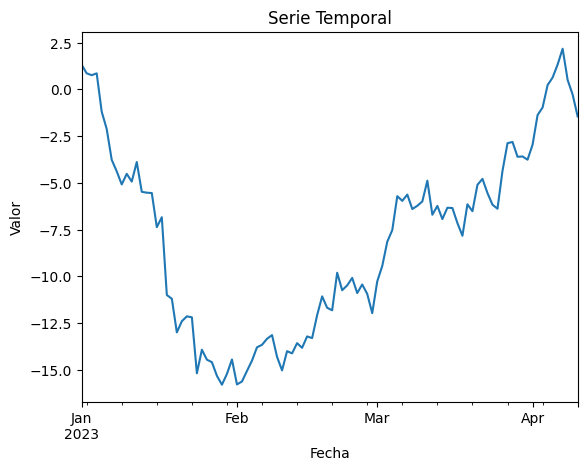

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Crear una serie temporal con datos aleatorios
data = pd.DataFrame({
    'fecha': pd.date_range(start='2023-01-01', periods=100, freq='D'),
    'valor': np.random.randn(100).cumsum()
})

data.set_index('fecha', inplace=True)

# Graficar la serie temporal
data['valor'].plot(title='Serie Temporal')

plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.show()

### 9. **Resampling con Agregaciones Personalizadas**

Además de sumar o promediar, puedes aplicar cualquier función personalizada al re-muestrear los datos.

#### Ejemplo de re-muestreo con agregación personalizada:

In [12]:
# Re-muestrear por mes y aplicar diferentes agregaciones
data_resample = data.resample('ME').agg({
    'valor': ['sum', 'mean', 'max']
})

print(data_resample)

                 valor                     
                   sum       mean       max
fecha                                      
2023-01-31 -247.722223  -7.991039  1.314807
2023-02-28 -358.255122 -12.794826 -9.807338
2023-03-31 -185.394345  -5.980463 -2.813601
2023-04-30   -2.183187  -0.218319  2.172313


### 10. **Manipulación Avanzada de Series Temporales**

#### Descomposición estacional:

Puedes descomponer una serie temporal en sus componentes estacionales, tendencia y residuales usando `statsmodels`.

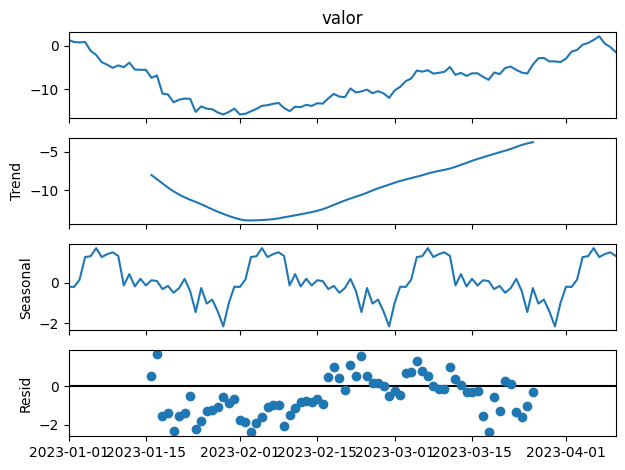

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Descomponer la serie temporal
resultado = seasonal_decompose(data['valor'], model='additive', period=30)

# Graficar los resultados de la descomposición
resultado.plot()

plt.show()

#### Ajuste de zonas horarias (time zones):

Pandas permite ajustar y convertir zonas horarias de manera eficiente.

In [14]:
# Convertir a zona horaria UTC

data = data.tz_localize('UTC')

# Convertir a una nueva zona horaria
data = data.tz_convert('America/New_York')

print(data)

                              valor
fecha                              
2022-12-31 19:00:00-05:00  1.314807
2023-01-01 19:00:00-05:00  0.857826
2023-01-02 19:00:00-05:00  0.756520
2023-01-03 19:00:00-05:00  0.855906
2023-01-04 19:00:00-05:00 -1.191631
...                             ...
2023-04-05 20:00:00-04:00  1.323517
2023-04-06 20:00:00-04:00  2.172313
2023-04-07 20:00:00-04:00  0.503052
2023-04-08 20:00:00-04:00 -0.280188
2023-04-09 20:00:00-04:00 -1.448328

[100 rows x 1 columns]


### Resumen de Operaciones Clave:

- **`pd.date_range()`**: Para crear series de fechas.

- **`pd.to_datetime()`**: Para convertir columnas de fechas.

- **`set_index()`**: Para establecer fechas como índice.

- **`resample()`**: Para cambiar la frecuencia temporal.

- **`shift()`**: Para desplazar datos en el tiempo.

- **`rolling()`**: Para aplicar funciones sobre ventanas móviles.

- **`tz_localize()` y `tz_convert()`**: Para ajustar zonas horarias.